### Cargar librerias

In [1]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
import scipy.stats as stats

# Fijar semilla para reproducibilidad
np.random.seed(42)
print("Librerías cargadas. Semilla configurada para reproducibilidad.")

Librerías cargadas. Semilla configurada para reproducibilidad.


## Simulación de Datos y Preparación (Fase Configure & Build)

Simularemos el comportamiento del inventario para 5 tiendas y 15 productos (SKUs) a lo largo de 30 semanas de operación.

In [2]:
tiendas = ['Tienda_A', 'Tienda_B', 'Tienda_C', 'Tienda_D', 'Tienda_E']
skus = [f'SKU_{i:02d}' for i in range(1, 16)]
semanas = list(range(1, 31))

# Generar demanda base semanal promedio para cada par Tienda-SKU
demanda_base = {(t, s): np.random.uniform(8, 35) for t in tiendas for s in skus}

filas = []
for (t, s), base in demanda_base.items():
    stock_actual = int(base * 2.5) # stock inicial
    reposicion_recibida = 0
    
    for w in semanas:
        # Stock al inicio de la semana w
        stock_disponible = stock_actual + reposicion_recibida
        
        # Demanda de la semana
        demanda_real = np.random.poisson(base)
        
        # Ventas limitadas por la disponibilidad física
        ventas = min(stock_disponible, demanda_real)
        
        # Stock final de la semana
        stock_final = stock_disponible - ventas
        
        # Target: 1 si hubo ruptura o si el stock final es muy bajo (menos del 30% del promedio)
        ruptura = 1 if demanda_real > stock_disponible else 0
        necesita_reposicion = 1 if (ruptura == 1 or stock_final < 0.3 * base) else 0
        
        # Simulación de la política histórica manual con ineficiencias
        if stock_final < 1.2 * base:
            reposicion_recibida = int(base * 2.5 - stock_final) if np.random.rand() < 0.70 else 0
        else:
            reposicion_recibida = 0
            
        filas.append({
            'Semana': w, 'Tienda': t, 'SKU': s, 'Ventas': ventas,
            'Stock_Final': stock_final, 'Necesita_Reposicion': necesita_reposicion
        })
        stock_actual = stock_final

df = pd.DataFrame(filas)
print(f"Registros simulados creados: {df.shape[0]}")

Registros simulados creados: 2250


### Ingeniería de Variables (Controles Anti-Leakage)

Construiremos variables explicativas utilizando únicamente datos del pasado (semanas $t-1$ y anteriores):

In [3]:
df = df.sort_values(by=['Tienda', 'SKU', 'Semana']).reset_index(drop=True)

# Rezagos de ventas e inventario
df['Ventas_lag1'] = df.groupby(['Tienda', 'SKU'])['Ventas'].shift(1)
df['Ventas_lag2'] = df.groupby(['Tienda', 'SKU'])['Ventas'].shift(2)
df['Ventas_lag3'] = df.groupby(['Tienda', 'SKU'])['Ventas'].shift(3)
df['Stock_Final_lag1'] = df.groupby(['Tienda', 'SKU'])['Stock_Final'].shift(1)
df['Stock_Final_lag2'] = df.groupby(['Tienda', 'SKU'])['Stock_Final'].shift(2)

# Estadísticas móviles sobre rezagos (pasado)
df['Ventas_mean_3w'] = (df['Ventas_lag1'] + df['Ventas_lag2'] + df['Ventas_lag3']) / 3.0
df['Ventas_std_3w'] = df[['Ventas_lag1', 'Ventas_lag2', 'Ventas_lag3']].std(axis=1)

# Ratios y tendencias explicativas
df['Stock_Ventas_Ratio_lag1'] = df['Stock_Final_lag1'] / (df['Ventas_mean_3w'] + 1.0)
df['Stock_Tendencia'] = df['Stock_Final_lag1'] - df['Stock_Final_lag2']

# Remover filas con valores nulos debido a los rezagos iniciales
df_ml = df.dropna().copy()
print(f"Registros disponibles tras remover lags nulos: {df_ml.shape[0]}")

Registros disponibles tras remover lags nulos: 2025


## Modelamiento Predictivo (Pipeline Reproducible)

Dividimos los datos temporalmente y configuramos un pipeline de entrenamiento reproducible.

In [4]:
features = [
    'Ventas_lag1', 'Ventas_lag2', 'Ventas_lag3',
    'Stock_Final_lag1', 'Stock_Final_lag2',
    'Ventas_mean_3w', 'Ventas_std_3w',
    'Stock_Ventas_Ratio_lag1', 'Stock_Tendencia'
]
target = 'Necesita_Reposicion'

# División temporal
train_df = df_ml[df_ml['Semana'] <= 20]
val_df = df_ml[(df_ml['Semana'] >= 21) & (df_ml['Semana'] <= 25)]
test_df = df_ml[df_ml['Semana'] >= 26]

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
X_test, y_test = test_df[features], test_df[target]

# Pipeline reproducible
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, C=1.0, max_iter=1000))
])

pipeline.fit(X_train, y_train)
print("Pipeline del modelo base entrenado exitosamente.")

Pipeline del modelo base entrenado exitosamente.


## Evaluación del Modelo 

Evaluamos la capacidad del clasificador y su desempeño práctico bajo la restricción de despachos semanales ($K=15$).

In [5]:
y_val_pred = pipeline.predict(X_val)
y_val_proba = pipeline.predict_proba(X_val)[:, 1]

print("=== Métricas Clásicas de Clasificación ===")
print(classification_report(y_val, y_val_pred))
print(f"ROC-AUC en Validación: {roc_auc_score(y_val, y_val_proba):.4f}")

=== Métricas Clásicas de Clasificación ===
              precision    recall  f1-score   support

           0       0.76      1.00      0.86       285
           1       0.00      0.00      0.00        90

    accuracy                           0.76       375
   macro avg       0.38      0.50      0.43       375
weighted avg       0.58      0.76      0.66       375

ROC-AUC en Validación: 0.5622


C:\Users\gonza\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gonza\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gonza\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [6]:
def evaluar_captura_top_k(df_eval, probabilidades, k=15):
    df_eval_copy = df_eval.copy()
    df_eval_copy['Probabilidad'] = probabilidades
    
    resultados = []
    for sem in df_eval_copy['Semana'].unique():
        df_sem = df_eval_copy[df_eval_copy['Semana'] == sem]
        top_k = df_sem.sort_values(by='Probabilidad', ascending=False).head(k)
        
        total_reales = df_sem['Necesita_Reposicion'].sum()
        capturados = top_k['Necesita_Reposicion'].sum()
        tasa_captura = (capturados / total_reales) if total_reales > 0 else 1.0
        
        resultados.append({
            'Semana': sem, 'Total_Reales': total_reales, 
            'Capturados_TopK': capturados, 'Tasa_Captura': tasa_captura
        })
    return pd.DataFrame(resultados)

reporte_val = evaluar_captura_top_k(val_df, y_val_proba, k=15)
print("=== Evaluación Operativa Top-15 por Semana (Validación) ===")
print(reporte_val.to_string(index=False))
print(f"\nTasa de Captura Promedio: {reporte_val['Tasa_Capture' if 'Tasa_Capture' in reporte_val else 'Tasa_Captura'].mean()*100:.2f}%")

=== Evaluación Operativa Top-15 por Semana (Validación) ===
 Semana  Total_Reales  Capturados_TopK  Tasa_Captura
     21            15                2      0.133333
     22            21                4      0.190476
     23            16                5      0.312500
     24            17                4      0.235294
     25            21                4      0.190476

Tasa de Captura Promedio: 21.24%


## Despliegue Operativo: Exportación de Lista Priorizada (Top-K)

Generamos y exportamos la lista operativa de despacho para el inicio de la **Semana 26**.

In [7]:
df_sem26 = test_df[test_df['Semana'] == 26].copy()
df_sem26['Probabilidad_Urgencia'] = pipeline.predict_proba(df_sem26[features])[:, 1]

# Filtrar los Top-15 prioritarios
top_k_semana26 = df_sem26.sort_values(by='Probabilidad_Urgencia', ascending=False).head(15).copy()
top_k_semana26['Prioridad'] = range(1, 16)

lista_despacho = top_k_semana26[['Prioridad', 'Tienda', 'SKU', 'Probabilidad_Urgencia', 'Semana']]
lista_despacho.to_csv('top_k_reposicion_semana_26.csv', index=False)
print("Lista de despacho de la semana 26 exportada con éxito.")
print("\n--- LISTA OPERATIVA SEMANA 26 ---")
print(lista_despacho.to_string(index=False))

Lista de despacho de la semana 26 exportada con éxito.

--- LISTA OPERATIVA SEMANA 26 ---
 Prioridad   Tienda    SKU  Probabilidad_Urgencia  Semana
         1 Tienda_D SKU_08               0.341967      26
         2 Tienda_B SKU_01               0.338490      26
         3 Tienda_A SKU_07               0.329398      26
         4 Tienda_A SKU_02               0.322120      26
         5 Tienda_D SKU_03               0.321592      26
         6 Tienda_E SKU_08               0.320449      26
         7 Tienda_B SKU_08               0.316131      26
         8 Tienda_C SKU_04               0.311612      26
         9 Tienda_A SKU_05               0.310711      26
        10 Tienda_D SKU_10               0.299912      26
        11 Tienda_A SKU_10               0.297605      26
        12 Tienda_E SKU_05               0.297117      26
        13 Tienda_B SKU_05               0.292806      26
        14 Tienda_B SKU_07               0.290912      26
        15 Tienda_A SKU_15              

## Monitoreo: Detección de Drift de Predicciones

Aplicamos el test estadístico de dos muestras Kolmogorov-Smirnov para evaluar si la distribución de las probabilidades predichas en el periodo de operación difiere de la del periodo de diseño (validación).

In [8]:
scores_val = pipeline.predict_proba(X_val)[:, 1]
scores_test = pipeline.predict_proba(X_test)[:, 1]

# Test KS
stat_ks, p_valor = stats.ks_2samp(scores_val, scores_test)
print("=== Reporte de Estabilidad de Modelo (KS Test) ===")
print(f"Estadístico KS: {stat_ks:.4f}")
print(f"p-valor: {p_valor:.4e}")

if p_valor < 0.05:
    print("\n[ALERTA DETECTADA] Cambio significativo en los scores (drift). Se requiere reentrenar el modelo.")
else:
    print("\n[SISTEMA SALUDABLE] Sin indicios de drift. El modelo es estable.")

=== Reporte de Estabilidad de Modelo (KS Test) ===
Estadístico KS: 0.0693
p-valor: 3.2858e-01

[SISTEMA SALUDABLE] Sin indicios de drift. El modelo es estable.


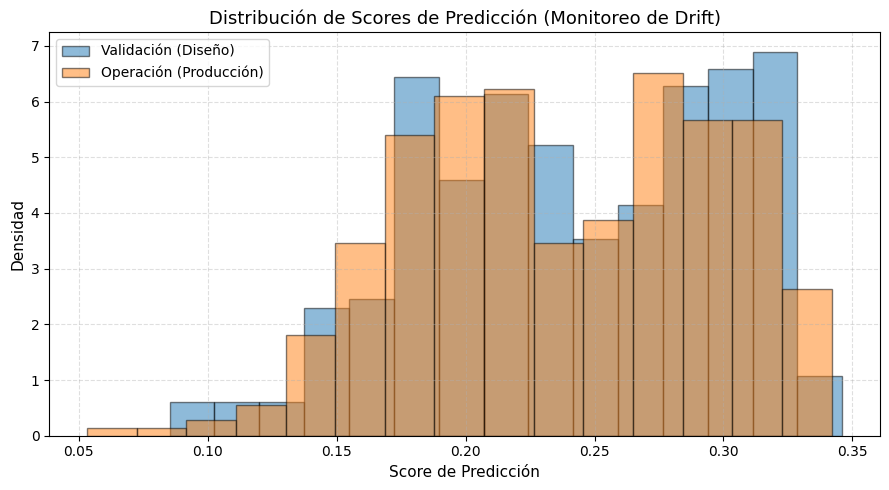

In [9]:
# Visualización de la densidad de scores para reportar
plt.figure(figsize=(9, 5))
plt.hist(scores_val, bins=15, alpha=0.5, label='Validación (Diseño)', color='#1f77b4', edgecolor='black', density=True)
plt.hist(scores_test, bins=15, alpha=0.5, label='Operación (Producción)', color='#ff7f0e', edgecolor='black', density=True)
plt.title('Distribución de Scores de Predicción (Monitoreo de Drift)', fontsize=13)
plt.xlabel('Score de Predicción', fontsize=11)
plt.ylabel('Densidad', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()